# Quick Start 

### Install / Load Libraries 

In [1]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("ComplexHeatmap")
BiocManager::install("ggtree")

install.packages("future")
install.packages("progressr")
install.packages("future.apply")
install.packages("tidyverse")
install.packages("ape")
install.packages("paleotree")
install.packages("nloptr")
install.packages("Matrix")
install.packages("corpcor")

Bioconductor version '3.20' is out-of-date; the current release version '3.23'
  is available with R version '4.6'; see https://bioconductor.org/install

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'ComplexHeatmap'”
Installation paths not writeable, unable to update packages
  path: /usr/lib64/R/library
  packages:
    Biobase, BiocGenerics, BiocVersion, bitops, boot, class, cluster,
    DelayedArray, foreign, GenomeInfoDbData, GenomicRanges, IRanges,
    KernSmooth, lattice, MASS, matrixStats, mgcv, nnet, S4Vectors,
    SingleCellExperiment, spatial, SummarizedExperiment, survival, XVector,
    zlibbioc

Old packages: 'ade4', 'airr', 'akima'

In [2]:
library(SCOUT)
library(progressr)
library(future.apply)
library(corpcor)
library(paleotree)
library(nloptr)
library(dplyr)
library(stringr)

Warning message:
“multiple methods tables found for ‘union’”
Warning message:
“multiple methods tables found for ‘intersect’”
Warning message:
“multiple methods tables found for ‘setdiff’”
Warning message:
“multiple methods tables found for ‘setequal’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘SummarizedExperiment’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘IRanges’”
Warning message:
“multiple methods tables found for ‘union’”
Warning message:
“multiple methods tables found for ‘intersect’”
Warning message:
“multiple methods tables found for ‘setdiff’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘GenomeInfoDb’”
Warning message:
“multiple methods tables found for ‘intersect’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘GenomicRanges

### Run SCOUT   
Required inputs: counts file with hypothesized regime information, tree in newick format, list of models to test. 

ggtree v4.3.0 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Guangchuang Yu.  Data Integration, Manipulation and Visualization of
Phylogenetic Trees (1st edition). Chapman and Hall/CRC. 2022,
doi:10.1201/9781003279242, ISBN: 9781032233574


Attaching package: ‘ggtree’


The following object is masked from ‘package:ape’:

    rotate




,BM1_1,BM1_2,BM1_3,BM1_4,BM1_5,OUM_30,OUM,species
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,1525,37,64,856,5,75,2,t1
2,1080,208,40,813,6,10,2,t2
3,2037,1197,25,857,1,3,2,t3
4,3446,1257,16,644,2,41,2,t4
5,965,1149,9,1243,0,170,2,t5
6,2071,1191,31,1095,69,11,2,t6


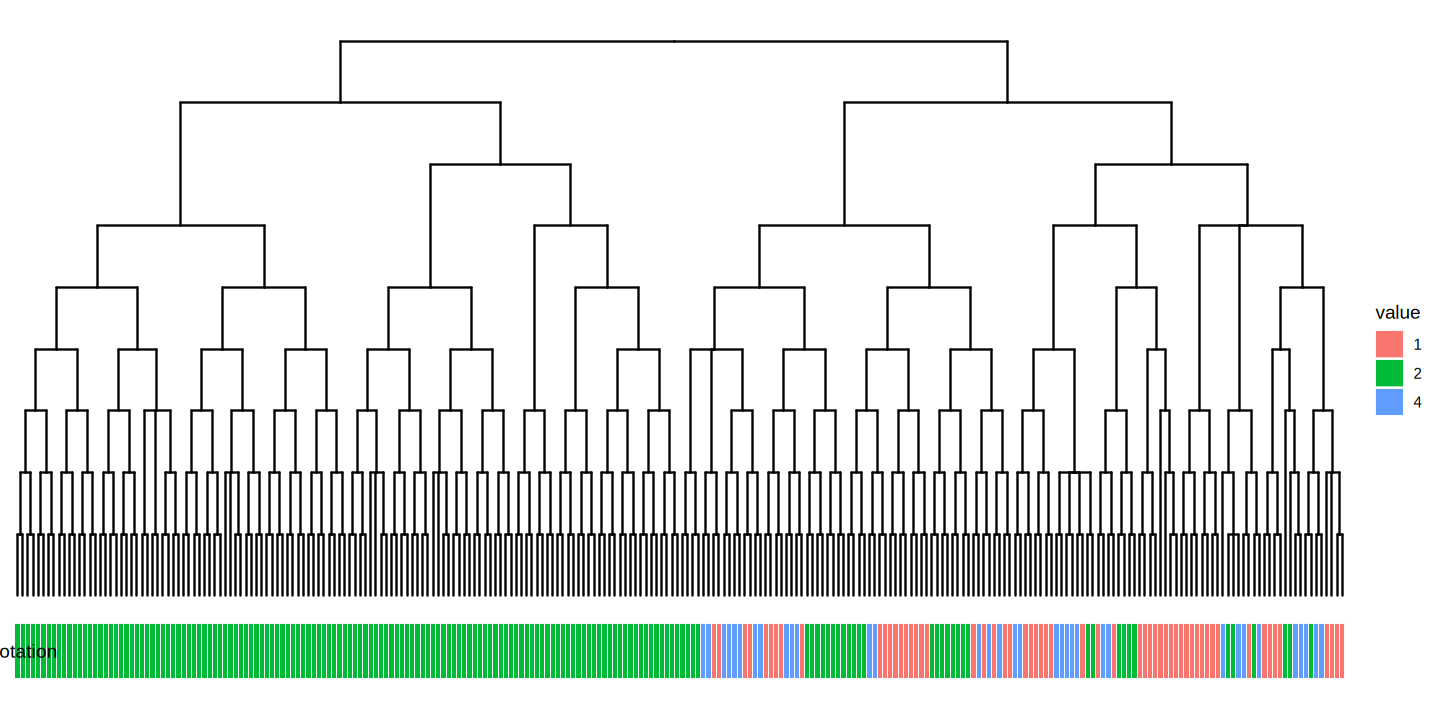

In [3]:
library(ggtree)
options(repr.plot.width = 12, repr.plot.height = 6)

# visualize inputs 
counts_data <- read.csv('./sim_example/3state_n256_alpha_3_sigma_1_counts.csv', row.names=1)
head(counts_data[, c(1:5, 90:92)])

tree_dat <- ape::read.tree('./sim_example/3state_n256_casNJ_tree.nwk')
annotation <- as.factor(counts_data$OUM)
names(annotation) <- counts_data$species

# Create tree plot with state annotations
p <- ggtree(tree_dat) + layout_dendrogram()
gheatmap(p, data.frame(annotation), width = 0.1)

In [4]:
# Run SCOUT 
scout.res <- SCOUT(counts.file = './sim_example/3state_n256_alpha_3_sigma_1_counts.csv',
    tree.file = './sim_example/3state_n256_casNJ_tree.nwk',
    results_dir = "../output/3state_SCOUT",
    regimes = c("BM1", "OU1", "OUM"),
    cores = 32, 
    logfile = '../output/3state_SCOUT/logfile.log', 
    verbose=TRUE
)

Directory already exists: ./3state_SCOUT 


2026-05-29 17:32:13.795701 | Started logging @ ./3state_SCOUT/logfile.log

2026-05-29 17:32:13.800367 | Data will be saved to --> ./3state_SCOUT

2026-05-29 17:32:13.832332 | =========================================================


2026-05-29 17:32:13.888539 | Inferring gene list from input data columns.

2026-05-29 17:32:13.894852 | 90 genes were detected. 

2026-05-29 17:32:13.901993 | 256 leaves were found in the raw tree. 256 leaves intersect with species column.

2026-05-29 17:32:13.912782 | Preprocessing tree

2026-05-29 17:32:13.916389 | No edge lengths, replacing with 1s.

2026-05-29 17:32:13.917775 | 2026-05-29 17:32:13.917782 Log normalizing gene expression counts.

2026-05-29 17:32:13.927579 | Regime: BM1 Rcol: OU1 Model: BM1

2026-05-29 17:32:13.929032 | Regime: OU1 Rcol: OU1 Model: OU1

2026-05-29 17:32:14.218166 | Regime: OUM Rcol: OUM Model: OUM



Running 270 combinations. Results will be saved at run ID = SCOUT_LMaUa6Qf 


2026-05-29 17:32:37.369848 | Start time = 17:32:37


2026-05-29 17:47:29.210576 | End time = 17:47:29


2026-05-29 17:47:31.658261 | Done with initial analysis of SCOUT_LMaUa6Qf.

2026-05-29 17:47:31.667185 | =========================================================


2026-05-29 17:47:31.672113 | Processsing Results... Saving files to ./3state_SCOUT



**Outputs** \
`SCOUT_class` contains the best-fit model assignments for each gene with some fit metrics and alpha, sigma, tau parameters.  \
`SCOUT_param` contains all optimal values estimates for each gene and model. Filter further to get the estimates per best-fit gene/model. \
`SCOUT_input` contains the object with the 'painted' tree per model and input meta-data. 

In [5]:
# Best fit gene-models  
head(scout.res$SCOUT_class)

iter,loglik,sigma,alpha,tau,converge,gene_name,regime,model,param.count,ntips,AIC,AIC_weight
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
8,-369.8601,0.3662881,1e-10,0.2688891,converged,BM1_1,BM1,BM1,3,256,745.7201,1.0000000
9,-308.0040,0.2250548,1e-10,0.1934496,converged,BM1_10,BM1,BM1,3,256,622.0080,0.9989975
9,-354.9363,0.3201437,1e-10,0.2494519,converged,BM1_11,BM1,BM1,3,256,715.8725,0.9999967
9,-275.1719,0.1603242,1e-10,0.2579779,converged,BM1_12,BM1,BM1,3,256,556.3438,1.0000000
9,-322.7949,0.2497166,1e-10,0.2223368,converged,BM1_13,BM1,BM1,3,256,651.5898,0.9999984
9,-507.6336,1.0652420,1e-10,0.4342708,converged,BM1_14,BM1,BM1,3,256,1021.2672,0.9997583


In [6]:
# Note, this will produce all estimates for all models not just the best fit. Filter parameters to get estimates for the best fit. 
head(scout.res$SCOUT_params)

gene_name,tau,alpha,sigma,theta_1
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
BM1_1,0.2688891,1e-10,0.36628812,6.501420
BM1_2,0.4258761,1e-10,0.90703383,4.976978
BM1_3,0.3300039,1e-10,0.23187318,4.537312
BM1_4,0.1462181,1e-10,0.07606497,6.340940
BM1_5,0.3800705,1e-10,0.99117123,2.334283
BM1_6,0.2040433,1e-10,0.12884093,6.505971
BM1_7,0.4926527,1e-10,0.94425531,5.224837
BM1_8,0.1584422,1e-10,0.06551987,5.952873
BM1_9,0.5947235,1e-10,1.87530186,2.940236
